In [108]:
# autoreload
%load_ext autoreload
%autoreload 2

from networks.novel.lite_vae.blocks.haar import HaarTransform
import torch
# from networks.novel.lite_vae.blocks.smc         import SMC
# from networks.novel.lite_vae.blocks.resblock    import ResBlock, ResBlockWithSMC
# from networks.novel.lite_vae.blocks.midblock    import MidBlock2D
# from networks.novel.lite_vae.blocks.unet_block  import LiteVAEUNetBlock
# from networks.novel.lite_vae.encoder            import LiteVAEEncoder
# from networks.novel.lite_vae.decoder            import *  # or SDVAEDecoder
# from networks.novel.lite_vae.litevae            import LiteVAE


import torch
import numpy as np
from data.image_dataset import *
from torch.utils.data import DataLoader
from PIL import Image
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [109]:
# Simulate grayscale images
haar = HaarTransform(levels = 3)

img_1 = Image.open(os.path.join('Dataset/busi/images/benign_1.png')).convert("RGB")
img_2 = Image.open(os.path.join('Dataset/busi/images/benign_2.png')).convert("RGB")

# stack them on the batch dimension and convert to tensor (B, C, H, W)
img = torch.stack([torch.tensor(np.array(img_1).transpose(2, 0, 1)), 
                   torch.tensor(np.array(img_2).transpose(2, 0, 1))]).float()
img.shape

train_dataset    = Image_Dataset('Dataset/busi/busi_train_test_names.pkl', stage="train", excel = False)
train_dataloader = DataLoader(
        train_dataset,
        batch_size = 12,
        pin_memory = True,
        drop_last  = True,
        shuffle    = True,
    )

In [ ]:
coeffs_all, coeffs_batch = haar(img, stacked_version=False, inverse = False, visualize = False)
coeffs_all_new, coeffs_batch_new = haar(img, stacked_version=False, inverse = False, visualize = False)

In [107]:
# unpack coeffs_batch and coeffs_batch_new
[(LL1, (LH1, HL1, HH1)), (LL2, (LH2, HL2, HH2)), (LL3, (LH3, HL3, HH3))] = coeffs_batch[0]
[(LL1_new, (LH1_new, HL1_new, HH1_new)), (LL2_new, (LH2_new, HL2_new, HH2_new)), (LL3_new, (LH3_new, HL3_new, HH3_new))] = coeffs_batch_new[1]

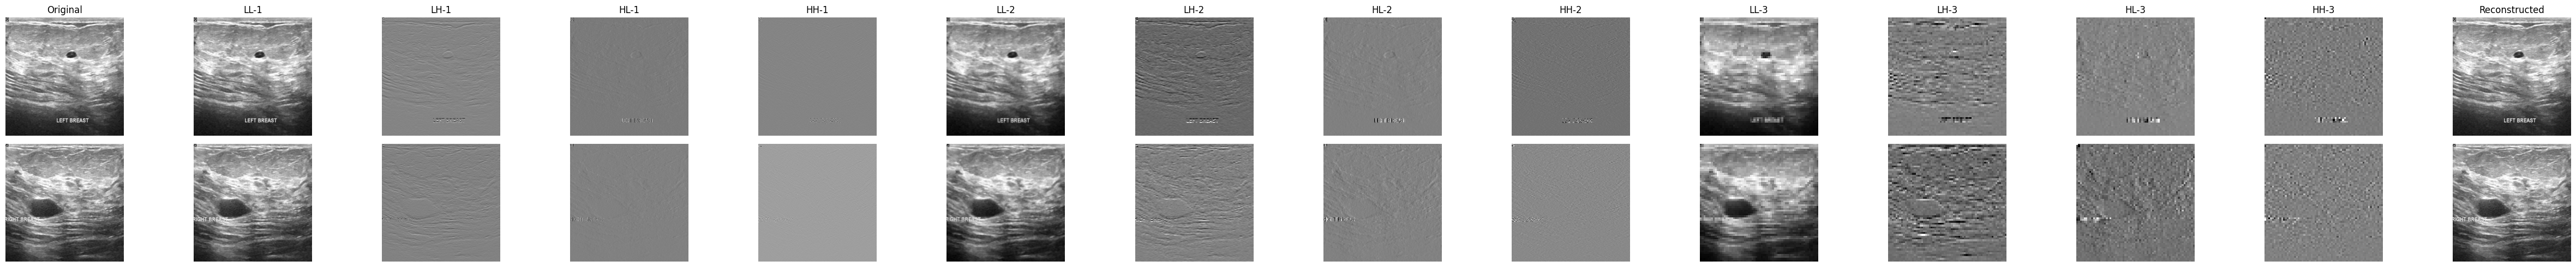

In [110]:
recon, haar_transform_out_list, haar_transform_out_dict = haar(img, stacked_version=True, inverse = True, visualize = True)

In [113]:
np.abs(recon - img).mean()

tensor(2.0284e-05)

In [21]:
haar_transform_out_list[0].shape

torch.Size([2, 4, 256, 256])

In [ ]:
x = torch.randn(4, 32, 56, 56)
rb = ResBlock(in_channels = 32, out_channels = 64)
y = rb(x)
y.shape  # (4, 64, 56, 56)

In [ ]:
x   = torch.randn(1, 64, 28, 28)
mid = MidBlock2D(64, 64, use_smc = False)
out = mid(x)
out.shape

In [ ]:
block = LiteVAEUNetBlock(3, 16, 32)
x = torch.randn(2, 3, 28, 28)
out = block(x)
out.shape
